#### HUC12 maps of aggregate water use

Creates HUC12 maps of public supply and irrigation water use. 

In [11]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable 
import tempfile
import imageio.v2 as imageio

# get filepath 
cd = Path.cwd() 

# create folder to store clean data 
out_dir = Path(f"{cd}/Figures/HUC12_water_use_maps")
out_dir.mkdir(parents=True, exist_ok=True)

In [12]:
##### ---------- MANUAL SET UP ----------

# for each scenario you want included in the figure, set scenario name, run date

scenarios = [
    {
        'scenario': 'calibration',
        'run_dates': {
            'GBSJ': '2026-07-16',
            'LCRR': '2026-07-16',
            'MILK': '2026-07-16',
        }
    }
]

In [13]:
##### ---------- IMPORT GEO BOUNDARIES ----------

GBSJ_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/GBSJ_HUC12.shp")
LCRR_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/LCRR_HUC12.shp")
MILK_huc12 = gpd.read_file("/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/MILK_HUC12.shp")

# get column in right format for merge 
GBSJ_huc12 = GBSJ_huc12.rename(columns={"huc12": "HUC12"})
LCRR_huc12 = LCRR_huc12.rename(columns={"huc12": "HUC12"})
MILK_huc12 = MILK_huc12.rename(columns={"huc12": "HUC12"})

GBSJ_huc12['HUC12'] = GBSJ_huc12['HUC12'].astype(int)
LCRR_huc12['HUC12'] = LCRR_huc12['HUC12'].astype(int)
MILK_huc12['HUC12'] = MILK_huc12['HUC12'].astype(int)

# prep CRS for maps
target_crs = GBSJ_huc12.crs

LCRR_huc12 = LCRR_huc12.to_crs(target_crs)
MILK_huc12 = MILK_huc12.to_crs(target_crs)

In [14]:
##### ---------- PREP DATA ----------

def prep_data(watershed, scenarios):

    ### ----- PREP USGS VALIDATION DATA -----
    USGS_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/USGS_validation.csv")

    data_for_fig = USGS_data

    ### ----- LOOP OVER SCENARIOS, MERGE EACH ONE IN -----
    all_regions = pd.read_csv('/netfiles/ciroh/cmanitiu/USGS/Data/Water_Basin_Boundaries/Filtered/HUC12/US_region_list.csv')
    all_regions = all_regions.rename(columns={'huc12': 'HUC12'})

    for s in scenarios:
        scenario = s['scenario']
        run_date = s['run_dates'][watershed]

        # load data
        model_data = pd.read_csv(f"{cd}/Clean_Data/{watershed}/{scenario}-{run_date}.csv")

        # filter out non-US HUCs
        model_data = model_data.merge(all_regions, on='HUC12', how='left')

        # sum by year and run_ID
        model_data_mean = (
            model_data
            .groupby(['Year', 'HUC12'])[
                [f'public_supply_mil_gal_{scenario}', f'irrigation_mil_gal_{scenario}']
            ]
            .mean()
            .reset_index()
        )

        # merge this scenario's columns into the growing data_for_fig
        data_for_fig = data_for_fig.merge(model_data_mean, on=['Year', 'HUC12'], how='outer')

    return data_for_fig

### ----- RUN FOR EACH WATERSHED -----

watersheds = ['GBSJ', 'LCRR', 'MILK']
data_for_fig = {w: prep_data(w, scenarios) for w in watersheds}

#### Single year PNG

/tmp/ipykernel_3589077/526202833.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])


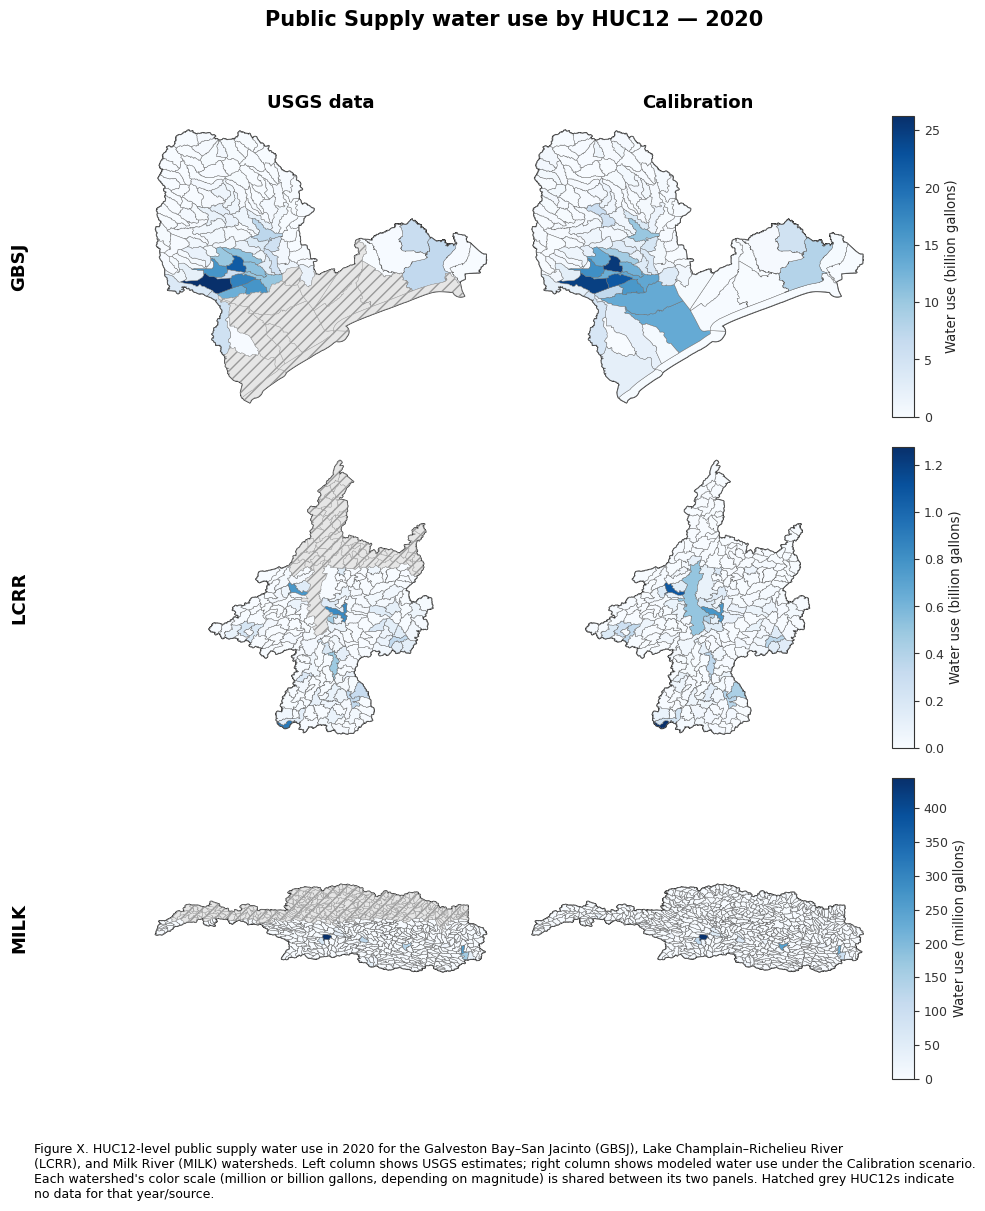

/tmp/ipykernel_3589077/526202833.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])


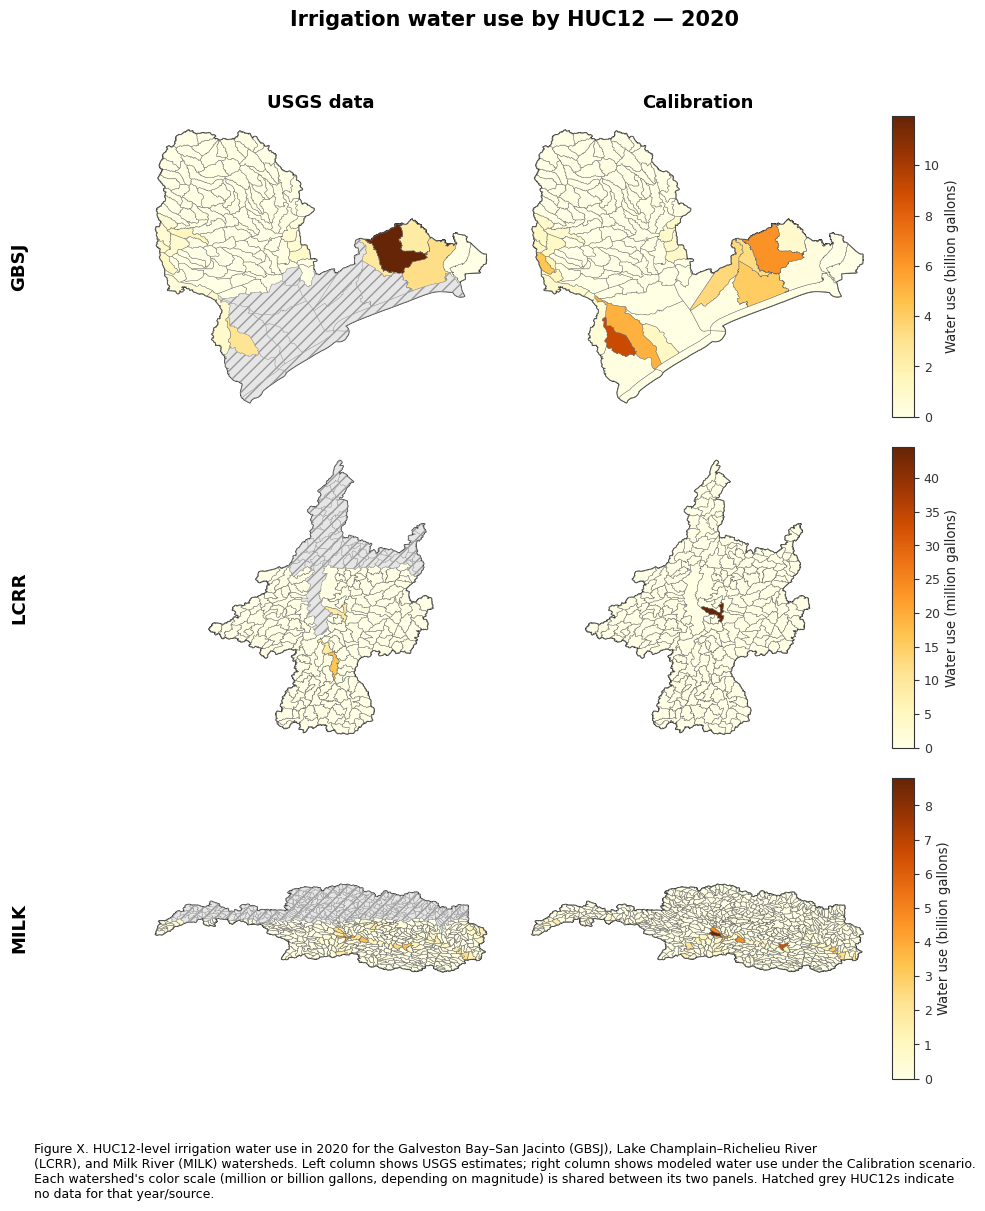

In [17]:
##### ---------- HUC12 CHOROPLETH MAPS: USGS vs. SCENARIO, BY WATERSHED ----------

##### ---------- MANUAL SET UP ----------

YEAR_TO_PLOT = 2020
SCENARIO_TO_PLOT = scenarios[0]['scenario']
SCENARIO_LABEL = scenarios[0].get('label', SCENARIO_TO_PLOT.title())

geo_lookup = {
    'GBSJ': GBSJ_huc12,
    'LCRR': LCRR_huc12,
    'MILK': MILK_huc12,
}

water_use_types = [
    ('public_supply', 'Public Supply', 'Blues'),
    ('irrigation', 'Irrigation', 'YlOrBr'),
]

##### ---------- STYLE ----------

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MISSING_KWDS = dict(color='#e6e6e6', edgecolor='#999999', linewidth=0.3, hatch='///', label='No data')
BOUNDARY_KWDS = dict(facecolor='none', edgecolor='#333333', linewidth=0.6)


def get_row_scale_and_unit(year_df, obs_col, scenario_col):
    """Shared vmin/vmax (already unit-scaled) + scale factor + unit label for one
    watershed/year, across both the USGS and scenario columns. Switches from
    million to billion gallons if the row's max value is >= 1000 million gallons."""
    vals = []
    for c in (obs_col, scenario_col):
        if c in year_df.columns:
            vals.append(year_df[c].dropna())
    if not vals or all(v.empty for v in vals):
        return 0, 1, 1, 'million gallons'

    all_vals = pd.concat(vals)
    raw_min, raw_max = float(all_vals.min()), float(all_vals.max())

    if raw_max >= 1000:
        scale, unit = 1000, 'billion gallons'
    else:
        scale, unit = 1, 'million gallons'

    return raw_min / scale, raw_max / scale, scale, unit


##### ---------- BUILD ONE FIGURE PER WATER-USE TYPE ----------

for use_key, use_label, cmap_name in water_use_types:

    fig = plt.figure(figsize=(10, 12.5))
    gs = gridspec.GridSpec(
        nrows=3, ncols=3, width_ratios=[1, 1, 0.06],
        wspace=0.05, hspace=0.10, figure=fig
    )

    obs_col = f'{use_key}_mil_gal_validation'
    scenario_col = f'{use_key}_mil_gal_{SCENARIO_TO_PLOT}'
    cmap = plt.get_cmap(cmap_name).copy()

    row_first_axes = []  

    for row, watershed in enumerate(watersheds):

        ax_obs = fig.add_subplot(gs[row, 0])
        ax_scn = fig.add_subplot(gs[row, 1])
        cax = fig.add_subplot(gs[row, 2])
        row_first_axes.append(ax_obs)

        geo = geo_lookup[watershed]
        df = data_for_fig[watershed]
        year_df = df[df['Year'] == YEAR_TO_PLOT]

        merged = geo.merge(year_df, on='HUC12', how='left')

        # ----- shared color scale + unit for this watershed row -----
        vmin, vmax, scale, unit = get_row_scale_and_unit(year_df, obs_col, scenario_col)
        norm = Normalize(vmin=vmin, vmax=vmax)

        # scaled columns to plot 
        obs_scaled_col = f'__{use_key}_obs_scaled'
        scn_scaled_col = f'__{use_key}_scn_scaled'
        merged[obs_scaled_col] = merged[obs_col] / scale if obs_col in merged.columns else np.nan
        merged[scn_scaled_col] = merged[scenario_col] / scale if scenario_col in merged.columns else np.nan

        panels = [(ax_obs, obs_scaled_col, obs_col, 'USGS data' if row == 0 else None),
                  (ax_scn, scn_scaled_col, scenario_col, SCENARIO_LABEL if row == 0 else None)]

        for ax, plot_col, raw_col, title in panels:
            if raw_col in merged.columns:
                merged.plot(
                    column=plot_col, cmap=cmap, norm=norm,
                    linewidth=0.3, edgecolor='#666666',
                    missing_kwds=MISSING_KWDS,
                    ax=ax, zorder=2
                )
            else:
                merged.plot(**MISSING_KWDS, ax=ax, zorder=2)

            # watershed outline on top
            geo.dissolve().boundary.plot(ax=ax, color='#333333', linewidth=1.2, zorder=0)

            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_aspect('equal')

            if title is not None:
                ax.set_title(title, fontsize=13, fontweight='bold', pad=6)

        # ----- shared colorbar for this row -----
        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax)
        cb.set_label(f'Water use ({unit})', fontsize=9.5)
        cb.ax.tick_params(labelsize=9)

    ##### ---------- SUPTITLE ----------
    fig.suptitle(
        f'{use_label} water use by HUC12 — {YEAR_TO_PLOT}',
        fontsize=15, fontweight='bold', y=0.965
    )

    ##### ---------- CAPTION ----------
    caption_text = (
        f"Figure X. HUC12-level {use_label.lower()} water use in {YEAR_TO_PLOT} for the Galveston Bay–San Jacinto (GBSJ), Lake Champlain–Richelieu River\n"
        f"(LCRR), and Milk River (MILK) watersheds. Left column shows USGS estimates; right column shows modeled water use under the {SCENARIO_LABEL} scenario.\n"
        f"Each watershed's color scale (million or billion gallons, depending on magnitude) is shared between its two panels. Hatched grey HUC12s indicate\n"
        f"no data for that year/source."
    )
    fig.text(0.02, 0.012, caption_text, ha='left', va='bottom', fontsize=9, wrap=True)

    fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])

    ##### ---------- ALIGN WATERSHED ROW LABELS ----------
    for watershed, ax in zip(watersheds, row_first_axes):
        pos = ax.get_position()
        y_center = (pos.y0 + pos.y1) / 2
        fig.text(
            0.005, y_center, watershed,
            rotation=90, va='center', ha='center',
            fontsize=13, fontweight='bold'
        )

    save_path = out_dir / f"{use_key}_{SCENARIO_TO_PLOT}_{YEAR_TO_PLOT}.png"
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

#### Multi-year GIF

In [ ]:
##### ---------- HUC12 CHOROPLETH GIF: USGS vs. SCENARIO, BY WATERSHED, 2000-2020 ----------

## NB: TAKES ~30 MIN TO RUN

##### ---------- MANUAL SET UP ----------

YEARS_TO_ANIMATE = range(2000, 2021)   # 2000-2020 inclusive
SCENARIO_TO_PLOT = scenarios[0]['scenario']
SCENARIO_LABEL = scenarios[0].get('label', SCENARIO_TO_PLOT.title())
FRAME_DPI = 150       # lower than the static PNG's 300 dpi, keeps GIF size reasonable
FRAME_DURATION = 0.8  # seconds per frame

geo_lookup = {
    'GBSJ': GBSJ_huc12,
    'LCRR': LCRR_huc12,
    'MILK': MILK_huc12,
}

water_use_types = [
    ('public_supply', 'Public Supply', 'Blues'),
    ('irrigation', 'Irrigation', 'YlOrBr'),
]

##### ---------- STYLE ----------

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MISSING_KWDS = dict(color='#e6e6e6', edgecolor='#999999', linewidth=0.3, hatch='///', label='No data')


def get_fixed_scale_and_unit(df, obs_col, scenario_col):
    """Fixed vmin/vmax/scale/unit across the FULL 2000-2020 record for one
    watershed, so the color scale (and million-vs-billion unit) stays constant
    across every frame of the animation."""
    vals = []
    for c in (obs_col, scenario_col):
        if c in df.columns:
            vals.append(df[c].dropna())
    if not vals or all(v.empty for v in vals):
        return 0, 1, 1, 'million gallons'

    all_vals = pd.concat(vals)
    raw_min, raw_max = float(all_vals.min()), float(all_vals.max())

    if raw_max >= 1000:
        scale, unit = 1000, 'billion gallons'
    else:
        scale, unit = 1, 'million gallons'

    return raw_min / scale, raw_max / scale, scale, unit


def build_frame(year, use_key, use_label, cmap_name, obs_col, scenario_col, row_scales):
    """Builds one full figure (all three watersheds) for a single year."""
    fig = plt.figure(figsize=(10, 12.5))
    gs = gridspec.GridSpec(
        nrows=3, ncols=3, width_ratios=[1, 1, 0.06],
        wspace=0.05, hspace=0.10, figure=fig
    )
    cmap = plt.get_cmap(cmap_name).copy()
    row_first_axes = []

    for row, watershed in enumerate(watersheds):

        ax_obs = fig.add_subplot(gs[row, 0])
        ax_scn = fig.add_subplot(gs[row, 1])
        cax = fig.add_subplot(gs[row, 2])
        row_first_axes.append(ax_obs)

        geo = geo_lookup[watershed]
        df = data_for_fig[watershed]
        year_df = df[df['Year'] == year]

        merged = geo.merge(year_df, on='HUC12', how='left')

        # ----- fixed color scale + unit for this watershed (same every frame) -----
        vmin, vmax, scale, unit = row_scales[watershed]
        norm = Normalize(vmin=vmin, vmax=vmax)

        obs_scaled_col = f'__{use_key}_obs_scaled'
        scn_scaled_col = f'__{use_key}_scn_scaled'
        merged[obs_scaled_col] = merged[obs_col] / scale if obs_col in merged.columns else np.nan
        merged[scn_scaled_col] = merged[scenario_col] / scale if scenario_col in merged.columns else np.nan

        panels = [(ax_obs, obs_scaled_col, obs_col, 'USGS data' if row == 0 else None),
                  (ax_scn, scn_scaled_col, scenario_col, SCENARIO_LABEL if row == 0 else None)]

        for ax, plot_col, raw_col, title in panels:
            if raw_col in merged.columns:
                merged.plot(
                    column=plot_col, cmap=cmap, norm=norm,
                    linewidth=0.3, edgecolor='#666666',
                    missing_kwds=MISSING_KWDS,
                    ax=ax, zorder=2
                )
            else:
                merged.plot(**MISSING_KWDS, ax=ax, zorder=2)

            geo.dissolve().boundary.plot(ax=ax, color='#333333', linewidth=1.2, zorder=0)

            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_aspect('equal')

            if title is not None:
                ax.set_title(title, fontsize=13, fontweight='bold', pad=6)

        sm = ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, cax=cax)
        cb.set_label(f'Water use ({unit})', fontsize=9.5)
        cb.ax.tick_params(labelsize=9)

    fig.suptitle(
        f'{use_label} water use by HUC12 — {year}',
        fontsize=15, fontweight='bold', y=0.965
    )

    caption_text = (
        f"Figure X. HUC12-level {use_label.lower()} water use in {year} for the Galveston Bay–San Jacinto (GBSJ), Lake Champlain–Richelieu River\n"
        f"(LCRR), and Milk River (MILK) watersheds. Left column shows USGS estimates; right column shows modeled water use under the {SCENARIO_LABEL} scenario.\n"
        f"Each watershed's color scale (million or billion gallons, depending on magnitude) is fixed across 2000–2020 and shared between its two panels.\n"
        f"Hatched grey HUC12s indicate no data for that year/source."
    )
    fig.text(0.02, 0.012, caption_text, ha='left', va='bottom', fontsize=9, wrap=True)

    fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])

    # ----- aligned watershed row labels -----
    for watershed, ax in zip(watersheds, row_first_axes):
        pos = ax.get_position()
        y_center = (pos.y0 + pos.y1) / 2
        fig.text(
            0.005, y_center, watershed,
            rotation=90, va='center', ha='center',
            fontsize=13, fontweight='bold'
        )

    return fig


##### ---------- BUILD ONE GIF PER WATER-USE TYPE ----------

for use_key, use_label, cmap_name in water_use_types:

    obs_col = f'{use_key}_mil_gal_validation'
    scenario_col = f'{use_key}_mil_gal_{SCENARIO_TO_PLOT}'

    # fixed scale per watershed, computed once across the full 2000-2020 record
    row_scales = {
        watershed: get_fixed_scale_and_unit(data_for_fig[watershed], obs_col, scenario_col)
        for watershed in watersheds
    }

    with tempfile.TemporaryDirectory() as tmp_dir:
        frame_paths = []

        for year in YEARS_TO_ANIMATE:
            fig = build_frame(year, use_key, use_label, cmap_name, obs_col, scenario_col, row_scales)
            frame_path = Path(tmp_dir) / f"{use_key}_{year}.png"
            # NOTE: no bbox_inches='tight' here -- frames must all be the same
            # pixel size for the GIF, and 'tight' can vary slightly frame to frame
            fig.savefig(frame_path, dpi=FRAME_DPI)
            plt.close(fig)
            frame_paths.append(frame_path)

        images = [imageio.imread(p) for p in frame_paths]
        gif_path = out_dir / f"{use_key}_{SCENARIO_TO_PLOT}_2000_2020.gif"
        imageio.mimsave(gif_path, images, duration=FRAME_DURATION, loop=0)
        print(f"Saved GIF: {gif_path}")

/tmp/ipykernel_3589077/3319001079.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])
/tmp/ipykernel_3589077/3319001079.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])
/tmp/ipykernel_3589077/3319001079.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])
/tmp/ipykernel_3589077/3319001079.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 1, 0.95])
/tmp/ipykernel_3589077/3319001079.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.03, 0.06, 